**Phase 1-- Data Cleaning**

In [266]:
import sys 
print(sys.executable)

c:\Users\bhatt\OneDrive\Desktop\LUCIDEX\Job Parser\.venv-1\Scripts\python.exe


In [267]:
import pandas as pd

df = pd.read_csv('C:\\Users\\bhatt\\OneDrive\\Desktop\\LUCIDEX\\Job Parser\\data\\indeed_jobs.csv')
df

,title,description,city,state,zipcode,salary,company,rating,reviews
0,Data Scientist,About Live Objects\nLive Objects delivers cont...,Palo Alto,CA,94301,NaN,LIVE OBJECTS,NaN,NaN
1,"Senior Data Scientist, FP&A","The Senior Data Scientist, FP&A role is primar...",Orrville,OH,44667,NaN,The J. M. Smucker Company,3.8,393.0
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,"$97,000 a year",Vaco,3.7,272.0
3,Search & Information Retrieval Engineer / Scie...,"Summary\nPosted: Jul 29, 2020\nRole Number:200...",Santa Clara Valley,CA,95014,NaN,Apple,4.2,9782.0
4,Machine Learning Engineer,"At Sisu, we're building a software platform th...",San Francisco,CA,NaN,NaN,Sisu,4.4,8.0
...,...,...,...,...,...,...,...,...,...
3191,"Data Scientist, Mars Petcare - Portland, OR",The Petcare Segment consists of five Divisions...,Portland,OR,97212,NaN,Mars,3.9,1790.0
3192,"Artificial Intelligence, Senior Consultant – A...","Artificial Intelligence, Senior Consultant – A...",San Jose,CA,95113,NaN,Deloitte,4.0,9750.0
3193,Data Scientist,Position Description\n\nCGI Federal is seeking...,Baltimore,MD,21203,NaN,"CGI Group, Inc.",3.6,2888.0
3194,"Professional, Advanced Analytics, Data Visuali...","AT&T is looking for a talented, highly motivat...",El Segundo,CA,90245,NaN,AT&T,3.8,42546.0


In [268]:
df['description']

0       About Live Objects\nLive Objects delivers cont...
1       The Senior Data Scientist, FP&A role is primar...
2       **U.S. Citizens and those authorized to work i...
3       Summary\nPosted: Jul 29, 2020\nRole Number:200...
4       At Sisu, we're building a software platform th...
                              ...                        
3191    The Petcare Segment consists of five Divisions...
3192    Artificial Intelligence, Senior Consultant – A...
3193    Position Description\n\nCGI Federal is seeking...
3194    AT&T is looking for a talented, highly motivat...
3195    We’re helping a major health insurer find seve...
Name: description, Length: 3196, dtype: str

In [269]:
df.columns.tolist()

['title',
 'description',
 'city',
 'state',
 'zipcode',
 'salary',
 'company',
 'rating',
 'reviews']

In [270]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3196 entries, 0 to 3195
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        3196 non-null   str    
 1   description  3196 non-null   str    
 2   city         3196 non-null   str    
 3   state        2936 non-null   str    
 4   zipcode      1433 non-null   str    
 5   salary       543 non-null    str    
 6   company      3196 non-null   str    
 7   rating       2051 non-null   float64
 8   reviews      2051 non-null   float64
dtypes: float64(2), str(7)
memory usage: 224.8 KB


In [271]:
df.describe(include='all')

,title,description,city,state,zipcode,salary,company,rating,reviews
count,3196,3196,3196,2936,1433,543,3196,2051.000000,2051.000000
unique,2280,3135,553,53,644,359,1816,NaN,NaN
top,Data Scientist,Thrive with Agiloft Are you an experienced Sen...,San Francisco,CA,95014,"Full-time, Contract",Apple,NaN,NaN
freq,244,5,261,1584,94,54,104,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.849098,5310.372989
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.463374,18290.370427
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,2.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.600000,23.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.900000,228.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.200000,2638.000000


In [272]:
df.isna().sum()

title             0
description       0
city              0
state           260
zipcode        1763
salary         2653
company           0
rating         1145
reviews        1145
dtype: int64

In [273]:
df.dtypes

title              str
description        str
city               str
state              str
zipcode            str
salary             str
company            str
rating         float64
reviews        float64
dtype: object

========================================================
Salary Correction
========================================================


In [274]:
df['salary']

0                  NaN
1                  NaN
2       $97,000 a year
3                  NaN
4                  NaN
             ...      
3191               NaN
3192               NaN
3193               NaN
3194               NaN
3195               NaN
Name: salary, Length: 3196, dtype: str

In [275]:
df['salary'].dtypes

<StringDtype(storage='python', na_value=nan)>

In [276]:
len(df['salary'].value_counts())

359

In [277]:
df['clean_salary'] = df['salary']
df['clean_salary'].dtype

<StringDtype(storage='python', na_value=nan)>

In [278]:
df.loc[df['clean_salary'].str.startswith('Full-Time'), 'clean_salary']


Series([], Name: clean_salary, dtype: str)

In [279]:
df['salary'] = df['salary'].str.replace(f'$', '', regex = False).str.replace(f',','', regex = False)

In [280]:
df['salary'].dropna()
df.shape

(3196, 10)

In [281]:
df['salary'].value_counts()

salary
Full-time Contract                                                           54
Full-time Part-time                                                          24
Full-time Temporary                                                           8
130000 a year                                                                 7
140000 - 160000 a year                                                        7
                                                                             ..
30 - 35 an hour                                                               1
50 - 60 an hour -  Full-time Contract                                         1
65000 a year                                                                  1
65000 - 75000 a year -  Full-time Temporary                                   1
50000 - 60000 a year -  Full-time Part-time Temporary Contract Internship     1
Name: count, Length: 359, dtype: int64

In [282]:
df['clean_salary'] = df['salary']

In [283]:
df['clean_salary'].unique()

<StringArray>
[                                                                        nan,
                                                              '97000 a year',
                                                      '45000 - 50000 a year',
                                                             '120000 a year',
                                                     '83692 - 111469 a year',
                                                           '80 - 90 an hour',
                                                     '21.93 - 26.43 an hour',
                                     '40 - 45 an hour -  Full-time Contract',
                                                           '31 - 40 an hour',
                                                      '55000 - 60000 a year',
 ...
                                                              '52000 a year',
                                        '80000 a year -  Full-time Contract',
                                             

In [284]:
df.loc[
    df['clean_salary'].str.contains(' - ', na =False) &
    df['clean_salary'].str.contains('a year', na = False), 'clean_salary'
].unique()

<StringArray>
[                                                     '45000 - 50000 a year',
                                                     '83692 - 111469 a year',
                                                      '55000 - 60000 a year',
                                                      '35000 - 40000 a year',
                                                    '100000 - 180000 a year',
                                                      '60000 - 70000 a year',
                                                    '125000 - 150000 a year',
                                                    '103700 - 168500 a year',
                                                    '100000 - 175000 a year',
                                                     '95000 - 105000 a year',
 ...
                                                    '102000 - 145000 a year',
                                                    '140000 - 175000 a year',
                                             

In [285]:
def convert_salary(x):
    x = str(x).replace('a year', '')
    x = str(x).replace('an hour', '')
    x = str(x).replace('a month', '')

    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

In [286]:
df['clean_salary'] = df['clean_salary'].astype(object)

In [287]:
year_range = (df['clean_salary'].str.contains(' - ', na=False) & 
            df['clean_salary'].str.contains('a year', na=False)) 

hour_range = (df['clean_salary'].str.contains(' - ', na=False) & 
              df['clean_salary'].str.contains('an hour', na=False))

per_hour = df['clean_salary'].str.contains('an hour', na=False)

month_range = (df['clean_salary'].str.contains(' - ', na=False) &
                df['clean_salary'].str.contains('a month', na=False))


In [288]:
df.loc[year_range, 'clean_salary'] = df.loc[year_range, 'clean_salary'].apply(convert_salary)
df.loc[hour_range, 'clean_salary'] = df.loc[hour_range, 'clean_salary'].apply(convert_salary)
df.loc[month_range, 'clean_salary'] = df.loc[month_range, 'clean_salary'].apply(convert_salary)
df.loc[per_hour, 'clean_salary'] = df.loc[per_hour,'clean_salary'].apply(convert_salary)

In [289]:
df['clean_salary'].value_counts()

clean_salary
Full-time Contract                    54
Full-time Part-time                   24
150000.0                              10
125000.0                              10
Full-time Temporary                    8
                                      ..
80000 a year -  Full-time Contract     1
53500.0                                1
Full-time Part-time Internship         1
32.5                                   1
65000 a year                           1
Name: count, Length: 217, dtype: int64

In [290]:
full_time = df['clean_salary'].str.contains('Full-time', na=False)
part_time = full_time = df['clean_salary'].str.contains('Full-time', na=False)


In [291]:
full_time = df['clean_salary'].str.contains('Full-time', na=False)
part_time = df['clean_salary'].str.contains('Part-time', na=False)

df.loc[full_time, 'clean_salary'] = 1
df.loc[part_time, 'clean_salary'] = 0


In [292]:
def remove_a_year(x):
    x = x.replace('a year', '')
    return x

In [293]:
a_year = df['clean_salary'].str.contains('a year', na=False)
df.loc[a_year, 'clean_salary'] = df.loc[a_year, 'clean_salary'].apply(remove_a_year)

In [294]:
df[df['clean_salary']==1]

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary
40,Database Developer,What matters to you about your work? Do you wa...,Richmond,VA,NaN,Full-time Contract,PeopleSolutions,NaN,NaN,1
109,Research Data Analyst,Our research group works on a range of quantit...,San Francisco,CA,94143,Full-time Contract,University of California San Francisco,4.2,455.0,1
110,Python Machine Learning Contractor,Python Machine Learning consultantLocation: Sa...,San Jose,CA,NaN,Full-time Contract,ALTEN Calsoft Labs,NaN,NaN,1
170,Senior Data Analyst,Python for data manipulation & transformation ...,Menlo Park,CA,NaN,Full-time Contract,Intersource,NaN,NaN,1
179,Database Lead,Required Skills (Technical Competency):\n1. Te...,Sunnyvale,CA,NaN,Full-time Temporary,QuEST Global Engineering,3.3,321.0,1
...,...,...,...,...,...,...,...,...,...,...
2982,"Oracle DBA - San Jose, CA.",Oracle DBA Minimum 8-10+ years of hands-on exp...,San Jose,CA,NaN,Full-time Contract,DXC Technology,3.2,3284.0,1
3008,Safety Data Scientist,Senior Scientist Patient Safety Scientist is n...,Gaithersburg,MD,20899,Full-time Contract,AstraZeneca Kelly OCG,NaN,NaN,1
3087,Teradata / Hadoop Developer,Candidate Description Blue Rose Technologies (...,San Jose,CA,NaN,Full-time Contract,Blue Rose Technologies,NaN,NaN,1
3090,Vehicle Data Analytics(ADAS) Machine Learning,ResponsibilitiesAnalyze source data and data f...,Auburn Hills,MI,NaN,Full-time Temporary Contract,"Detroit Engineered Products, Inc.",4.0,12.0,1


In [295]:
df['clean_salary'].unique()

array([nan, '97000 ', 47500.0, '120000 ', 97580.5, 85.0, 24.18, 35.5,
       57500.0, 1, 69.0, 37500.0, 140000.0, 65000.0, '180000 ', 137500.0,
       136100.0, 100000.0, 37.5, 'Up to 2000 a week', 5116.5, '220000 ',
       119175.0, 130000.0, 66691.5, 107500.0, 0, '75000 ', 217000.0,
       55000.0, 117384.5, 52500.0, 62500.0, 45000.0, 120000.0, 26.0,
       170000.0, 18.5, '2115 a month', 102974.5, 75000.0, 154465.5, 16.5,
       50000.0, 19.0, 31.885, 68450.0, 23.8, '130000 ', 'Up to 250000 ',
       17.5, 117742.5, 70417.5, 350000.0, 110000.0, 108500.0, 24.01,
       150000.0, '135000 ', '10000 a month', 'From 40000 ', '150000 ',
       95000.0, 102500.0, '107307 ', 35.0, 67500.0, 47.5, '31000 ', 80.0,
       147738.0, 152500.0, 113978.5, '200000 ', 47.0, 165000.0, 54000.0,
       'Contract', 155000.0, 127500.0, 72290.5, 51500.0, '155000 ',
       '87000 ', 22.42, 75.0, '165000 ', 166614.0, 105000.0, 89000.0,
       81254.0, 79044.5, 15.0, 21.82, 10708.0, 85000.0, 80000.0, 48500.0,

In [296]:
def remove_from(x):
    return x.replace("From ", "")

In [297]:
contain_from = df['clean_salary'].str.contains('From', na = False)
df.loc[contain_from, 'clean_salary'] = (df.loc[contain_from, 'clean_salary'].apply(remove_from))

In [298]:
df['clean_salary'].unique()

array([nan, '97000 ', 47500.0, '120000 ', 97580.5, 85.0, 24.18, 35.5,
       57500.0, 1, 69.0, 37500.0, 140000.0, 65000.0, '180000 ', 137500.0,
       136100.0, 100000.0, 37.5, 'Up to 2000 a week', 5116.5, '220000 ',
       119175.0, 130000.0, 66691.5, 107500.0, 0, '75000 ', 217000.0,
       55000.0, 117384.5, 52500.0, 62500.0, 45000.0, 120000.0, 26.0,
       170000.0, 18.5, '2115 a month', 102974.5, 75000.0, 154465.5, 16.5,
       50000.0, 19.0, 31.885, 68450.0, 23.8, '130000 ', 'Up to 250000 ',
       17.5, 117742.5, 70417.5, 350000.0, 110000.0, 108500.0, 24.01,
       150000.0, '135000 ', '10000 a month', '40000 ', '150000 ', 95000.0,
       102500.0, '107307 ', 35.0, 67500.0, 47.5, '31000 ', 80.0, 147738.0,
       152500.0, 113978.5, '200000 ', 47.0, 165000.0, 54000.0, 'Contract',
       155000.0, 127500.0, 72290.5, 51500.0, '155000 ', '87000 ', 22.42,
       75.0, '165000 ', 166614.0, 105000.0, 89000.0, 81254.0, 79044.5,
       15.0, 21.82, 10708.0, 85000.0, 80000.0, 48500.0, 'Up 

In [299]:
def remove_upto(x):
    x = str(x).strip()
    if x.startswith("Up to"):
        x = x.replace("Up to", "")
    return x

In [300]:
df['clean_salary'] = df['clean_salary'].apply(remove_upto)

In [301]:
df['clean_salary'].value_counts()

clean_salary
nan         2753
1             78
0             35
150000.0      10
125000.0      10
            ... 
160000         1
52000          1
53500.0        1
32.5           1
65000          1
Name: count, Length: 200, dtype: int64

In [302]:
df['clean_salary'] = pd.to_numeric(df['clean_salary'], errors = 'coerce')

In [303]:
median = df['clean_salary'].median()
median_half = median / 2
df['clean_salary'] = df['clean_salary'].replace(1, median)
df['clean_salary'] = df['clean_salary'].replace(0, median_half)
df['clean_salary'] = df['clean_salary'].fillna(median)

In [304]:
df['clean_salary'].unique()

array([6.750000e+04, 9.700000e+04, 4.750000e+04, 1.200000e+05,
       9.758050e+04, 8.500000e+01, 2.418000e+01, 3.550000e+01,
       5.750000e+04, 6.900000e+01, 3.750000e+04, 1.400000e+05,
       6.500000e+04, 1.800000e+05, 1.375000e+05, 1.361000e+05,
       1.000000e+05, 3.750000e+01, 5.116500e+03, 2.200000e+05,
       1.191750e+05, 1.300000e+05, 6.669150e+04, 1.075000e+05,
       3.375000e+04, 7.500000e+04, 2.170000e+05, 5.500000e+04,
       1.173845e+05, 5.250000e+04, 6.250000e+04, 4.500000e+04,
       2.600000e+01, 1.700000e+05, 1.850000e+01, 1.029745e+05,
       1.544655e+05, 1.650000e+01, 5.000000e+04, 1.900000e+01,
       3.188500e+01, 6.845000e+04, 2.380000e+01, 2.500000e+05,
       1.750000e+01, 1.177425e+05, 7.041750e+04, 3.500000e+05,
       1.100000e+05, 1.085000e+05, 2.401000e+01, 1.500000e+05,
       1.350000e+05, 4.000000e+04, 9.500000e+04, 1.025000e+05,
       1.073070e+05, 3.500000e+01, 4.750000e+01, 3.100000e+04,
       8.000000e+01, 1.477380e+05, 1.525000e+05, 1.1397

In [305]:
df.isna().sum()

title              0
description        0
city               0
state            260
zipcode         1763
salary          2653
company            0
rating          1145
reviews         1145
clean_salary       0
dtype: int64

In [306]:
df

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary
0,Data Scientist,About Live Objects\nLive Objects delivers cont...,Palo Alto,CA,94301,NaN,LIVE OBJECTS,NaN,NaN,67500.0
1,"Senior Data Scientist, FP&A","The Senior Data Scientist, FP&A role is primar...",Orrville,OH,44667,NaN,The J. M. Smucker Company,3.8,393.0,67500.0
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.0
3,Search & Information Retrieval Engineer / Scie...,"Summary\nPosted: Jul 29, 2020\nRole Number:200...",Santa Clara Valley,CA,95014,NaN,Apple,4.2,9782.0,67500.0
4,Machine Learning Engineer,"At Sisu, we're building a software platform th...",San Francisco,CA,NaN,NaN,Sisu,4.4,8.0,67500.0
...,...,...,...,...,...,...,...,...,...,...
3191,"Data Scientist, Mars Petcare - Portland, OR",The Petcare Segment consists of five Divisions...,Portland,OR,97212,NaN,Mars,3.9,1790.0,67500.0
3192,"Artificial Intelligence, Senior Consultant – A...","Artificial Intelligence, Senior Consultant – A...",San Jose,CA,95113,NaN,Deloitte,4.0,9750.0,67500.0
3193,Data Scientist,Position Description\n\nCGI Federal is seeking...,Baltimore,MD,21203,NaN,"CGI Group, Inc.",3.6,2888.0,67500.0
3194,"Professional, Advanced Analytics, Data Visuali...","AT&T is looking for a talented, highly motivat...",El Segundo,CA,90245,NaN,AT&T,3.8,42546.0,67500.0


In [307]:
df = df.dropna(subset= ['state', 'salary'])

In [308]:
df.shape

(509, 10)

In [309]:
df.isna().sum()

title             0
description       0
city              0
state             0
zipcode         260
salary            0
company           0
rating          235
reviews         235
clean_salary      0
dtype: int64

In [310]:
df['zipcode'] = df['zipcode'].astype('Int64')

In [311]:
df.isna().sum()

title             0
description       0
city              0
state             0
zipcode         260
salary            0
company           0
rating          235
reviews         235
clean_salary      0
dtype: int64

In [312]:
df.head()

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.00
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.00
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.00
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.2,246.0,97580.50
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.3,200.0,24.18


In [313]:
mean_columns = ['rating', 'reviews']
for i in mean_columns:
  mean = df[i].mean()
  df[i] = df[i].fillna(mean)

In [314]:
df.isna().sum()

title             0
description       0
city              0
state             0
zipcode         260
salary            0
company           0
rating            0
reviews           0
clean_salary      0
dtype: int64

In [315]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 8


In [316]:
df = df.drop_duplicates()
df

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.700000,272.000000,97000.00
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.800000,14581.000000,47500.00
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.600000,9.000000,120000.00
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.200000,246.000000,97580.50
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.300000,200.000000,24.18
...,...,...,...,...,...,...,...,...,...,...
3174,Data Analyst,Summary:\nThe Marin City Health and Wellness C...,Marin City,CA,<NA>,65000 a year,Marin City Health and Wellness Center,3.940511,1406.087591,65000.00
3184,Junior Business Analyst,This is a long term temporary position with be...,New York,NY,<NA>,65000 - 75000 a year - Full-time Temporary,"Penda Aiken, Inc.",3.940511,1406.087591,67500.00
3185,SQL Data Analyst,Role: SQL Data Analyst with Healthcare Payer E...,Portland,OR,<NA>,55 - 60 an hour - Full-time Contract,Peopleforce INC,3.940511,1406.087591,67500.00
3186,Data Analyst -Entry Level Job ( Skill upgradat...,Roles & Responsibility of Data AnalystA data a...,Boston,MA,2199,50000 - 60000 a year - Full-time Part-time Te...,Jerneltechcorp,3.940511,1406.087591,67500.00


In [317]:
df['title'].value_counts()

title
Data Scientist                                                      37
Data Analyst                                                        19
Senior Data Scientist                                                8
Data Engineer                                                        7
Business Analyst                                                     7
                                                                    ..
Jr. Data Analyst                                                     1
Senior Algorithm Engineer #ESF4457                                   1
PostgreSQL Database Developer (Remote) (Only GC, H4, L2 and USC)     1
SQL Data Analyst                                                     1
Data Analyst -Entry Level Job ( Skill upgradation If required )      1
Name: count, Length: 387, dtype: int64

In [318]:
df

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.700000,272.000000,97000.00
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.800000,14581.000000,47500.00
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.600000,9.000000,120000.00
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.200000,246.000000,97580.50
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.300000,200.000000,24.18
...,...,...,...,...,...,...,...,...,...,...
3174,Data Analyst,Summary:\nThe Marin City Health and Wellness C...,Marin City,CA,<NA>,65000 a year,Marin City Health and Wellness Center,3.940511,1406.087591,65000.00
3184,Junior Business Analyst,This is a long term temporary position with be...,New York,NY,<NA>,65000 - 75000 a year - Full-time Temporary,"Penda Aiken, Inc.",3.940511,1406.087591,67500.00
3185,SQL Data Analyst,Role: SQL Data Analyst with Healthcare Payer E...,Portland,OR,<NA>,55 - 60 an hour - Full-time Contract,Peopleforce INC,3.940511,1406.087591,67500.00
3186,Data Analyst -Entry Level Job ( Skill upgradat...,Roles & Responsibility of Data AnalystA data a...,Boston,MA,2199,50000 - 60000 a year - Full-time Part-time Te...,Jerneltechcorp,3.940511,1406.087591,67500.00


In [319]:
print(df['description'].iloc[0])

**U.S. Citizens and those authorized to work in the U.S. are encouraged to apply. We are unable to sponsor at this time.**

This position is primarily responsible for leveraging data warehouse and business intelligence services to advance the use of data and analytics. This position will be responsible for working on and developing various data and analytics projects that improve services and inform decisions.
Major Duties and Responsibilities
Provide accessible data and business intelligence solutions that support decision-making and problem-solving.
Partner with departments to design and implement the Enterprise Data Architecture a scalable framework for accessing and publishing data across the organization.
Assist with the administration of the Business Intelligence Infrastructure (Warehouse, Tableau Server, SSRS).
Data Warehouse Administration - Support Kimball, Inmon and/or Linstedt data architecture (WhereScape Red).
Design and implement visual analytics and enterprise reporting 

In [320]:
for i in range(5):
  print("=" * 80)
  print(df['description'].iloc[i])

**U.S. Citizens and those authorized to work in the U.S. are encouraged to apply. We are unable to sponsor at this time.**

This position is primarily responsible for leveraging data warehouse and business intelligence services to advance the use of data and analytics. This position will be responsible for working on and developing various data and analytics projects that improve services and inform decisions.
Major Duties and Responsibilities
Provide accessible data and business intelligence solutions that support decision-making and problem-solving.
Partner with departments to design and implement the Enterprise Data Architecture a scalable framework for accessing and publishing data across the organization.
Assist with the administration of the Business Intelligence Infrastructure (Warehouse, Tableau Server, SSRS).
Data Warehouse Administration - Support Kimball, Inmon and/or Linstedt data architecture (WhereScape Red).
Design and implement visual analytics and enterprise reporting 

In [321]:
df.head()

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.00
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.00
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.00
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.2,246.0,97580.50
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.3,200.0,24.18


In [322]:
jobs = df.copy()

jobs['title'] = jobs['title'].fillna('')
jobs['description'] = jobs['description'].fillna('')
jobs['city'] = jobs['city'].fillna('')
jobs['company'] = jobs['company'].fillna('')
jobs['state'] = jobs['state'].fillna('')


In [323]:
jobs['job_text'] = (jobs['title'] + ":--- " + jobs['description'])

In [324]:
jobs['job_text']

2       BI Developer (Tableau):--- **U.S. Citizens and...
10      Master Data Management Tool Admin:--- Roles an...
11      Senior Web Data Analyst - SQL:--- Senior Web D...
13      Software Engineer - Entry to Experienced Level...
25      Undergraduate Internship/Co-op Program - Data ...
                              ...                        
3174    Data Analyst:--- Summary:\nThe Marin City Heal...
3184    Junior Business Analyst:--- This is a long ter...
3185    SQL Data Analyst:--- Role: SQL Data Analyst wi...
3186    Data Analyst -Entry Level Job ( Skill upgradat...
3189    Data Scientist:--- Data Scientist\nIf you are ...
Name: job_text, Length: 501, dtype: str

In [325]:
jobs.head()

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.00,Master Data Management Tool Admin:--- Roles an...
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.2,246.0,97580.50,Software Engineer - Entry to Experienced Level...
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.3,200.0,24.18,Undergraduate Internship/Co-op Program - Data ...


In [326]:
jobs = jobs.drop_duplicates(subset = ["job_text"])
jobs.shape

(497, 11)

In [327]:
jobs = jobs[jobs['description'].str.len()>100]
jobs

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.700000,272.000000,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.800000,14581.000000,47500.00,Master Data Management Tool Admin:--- Roles an...
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.600000,9.000000,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.200000,246.000000,97580.50,Software Engineer - Entry to Experienced Level...
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.300000,200.000000,24.18,Undergraduate Internship/Co-op Program - Data ...
...,...,...,...,...,...,...,...,...,...,...,...
3174,Data Analyst,Summary:\nThe Marin City Health and Wellness C...,Marin City,CA,<NA>,65000 a year,Marin City Health and Wellness Center,3.940511,1406.087591,65000.00,Data Analyst:--- Summary:\nThe Marin City Heal...
3184,Junior Business Analyst,This is a long term temporary position with be...,New York,NY,<NA>,65000 - 75000 a year - Full-time Temporary,"Penda Aiken, Inc.",3.940511,1406.087591,67500.00,Junior Business Analyst:--- This is a long ter...
3185,SQL Data Analyst,Role: SQL Data Analyst with Healthcare Payer E...,Portland,OR,<NA>,55 - 60 an hour - Full-time Contract,Peopleforce INC,3.940511,1406.087591,67500.00,SQL Data Analyst:--- Role: SQL Data Analyst wi...
3186,Data Analyst -Entry Level Job ( Skill upgradat...,Roles & Responsibility of Data AnalystA data a...,Boston,MA,2199,50000 - 60000 a year - Full-time Part-time Te...,Jerneltechcorp,3.940511,1406.087591,67500.00,Data Analyst -Entry Level Job ( Skill upgradat...


In [328]:
jobs.info()

<class 'pandas.DataFrame'>
Index: 496 entries, 2 to 3189
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         496 non-null    str    
 1   description   496 non-null    str    
 2   city          496 non-null    str    
 3   state         496 non-null    str    
 4   zipcode       244 non-null    Int64  
 5   salary        496 non-null    str    
 6   company       496 non-null    str    
 7   rating        496 non-null    float64
 8   reviews       496 non-null    float64
 9   clean_salary  496 non-null    float64
 10  job_text      496 non-null    str    
dtypes: Int64(1), float64(3), str(7)
memory usage: 47.0 KB


In [329]:
jobs.info()

<class 'pandas.DataFrame'>
Index: 496 entries, 2 to 3189
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         496 non-null    str    
 1   description   496 non-null    str    
 2   city          496 non-null    str    
 3   state         496 non-null    str    
 4   zipcode       244 non-null    Int64  
 5   salary        496 non-null    str    
 6   company       496 non-null    str    
 7   rating        496 non-null    float64
 8   reviews       496 non-null    float64
 9   clean_salary  496 non-null    float64
 10  job_text      496 non-null    str    
dtypes: Int64(1), float64(3), str(7)
memory usage: 47.0 KB


In [330]:
title_counts = jobs['title'].value_counts()

**Job Analysis**

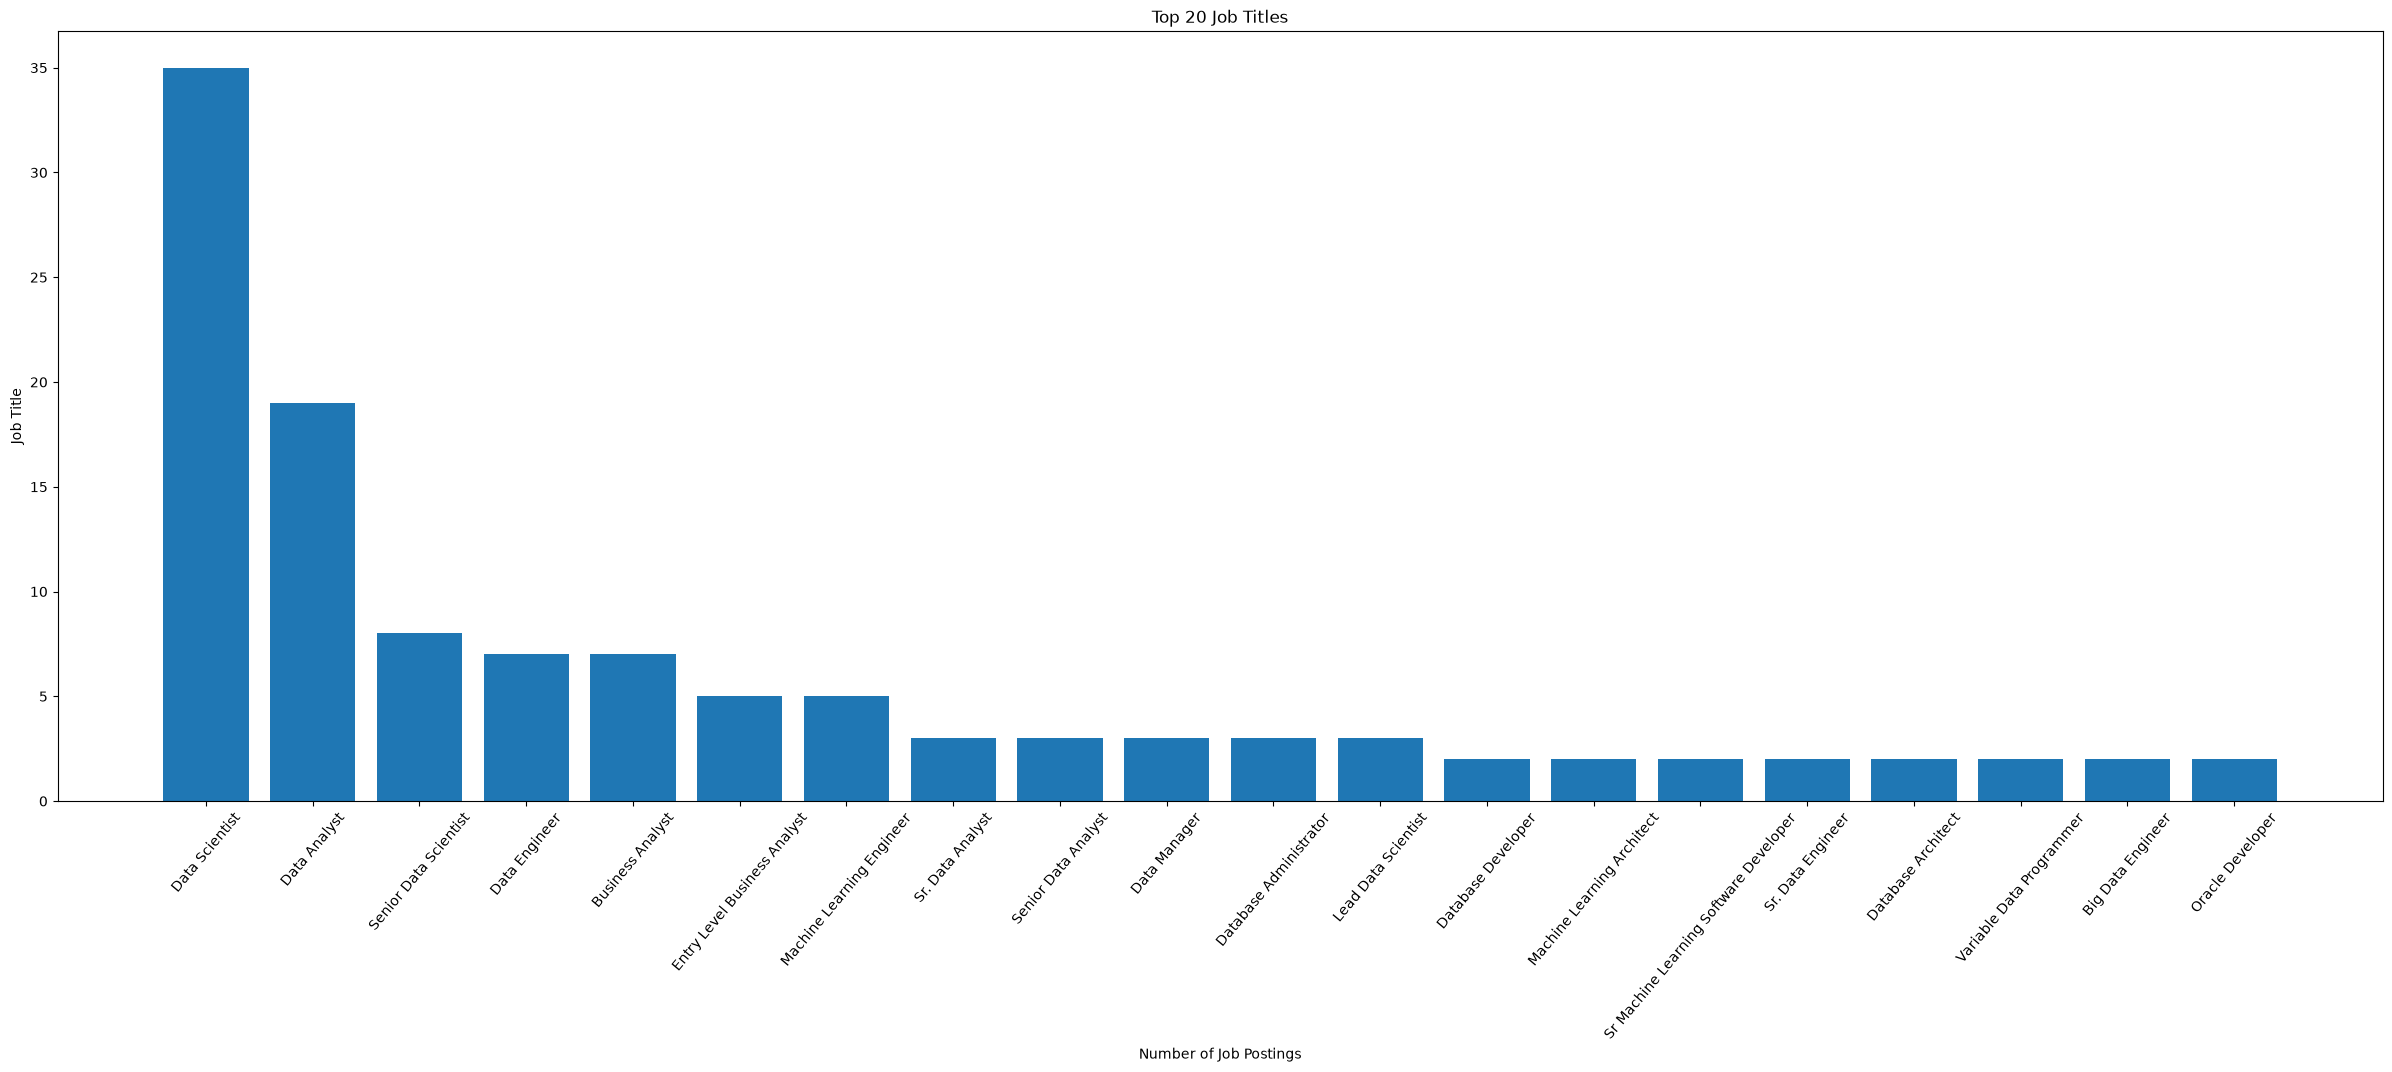

In [331]:
from matplotlib import pyplot as plt

top_titles = title_counts.head(20)
plt.figure(figsize=(30,10))

plt.bar(top_titles.index,
        top_titles.values)

plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")
plt.title("Top 20 Job Titles")

plt.xticks(rotation=50)
plt.show()


In [332]:
jobs.head()

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.00,Master Data Management Tool Admin:--- Roles an...
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.2,246.0,97580.50,Software Engineer - Entry to Experienced Level...
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.3,200.0,24.18,Undergraduate Internship/Co-op Program - Data ...


**State Analysis**

In [333]:
state_value = jobs['state'].value_counts().head(20)
state_value

state
CA    159
VA     32
TX     29
DC     25
NY     25
IL     17
MD     15
PA     15
MA     14
OH     14
GA     13
CO     13
NC     12
WA     11
AZ     10
NJ      9
FL      9
MI      9
MN      8
MO      6
Name: count, dtype: int64

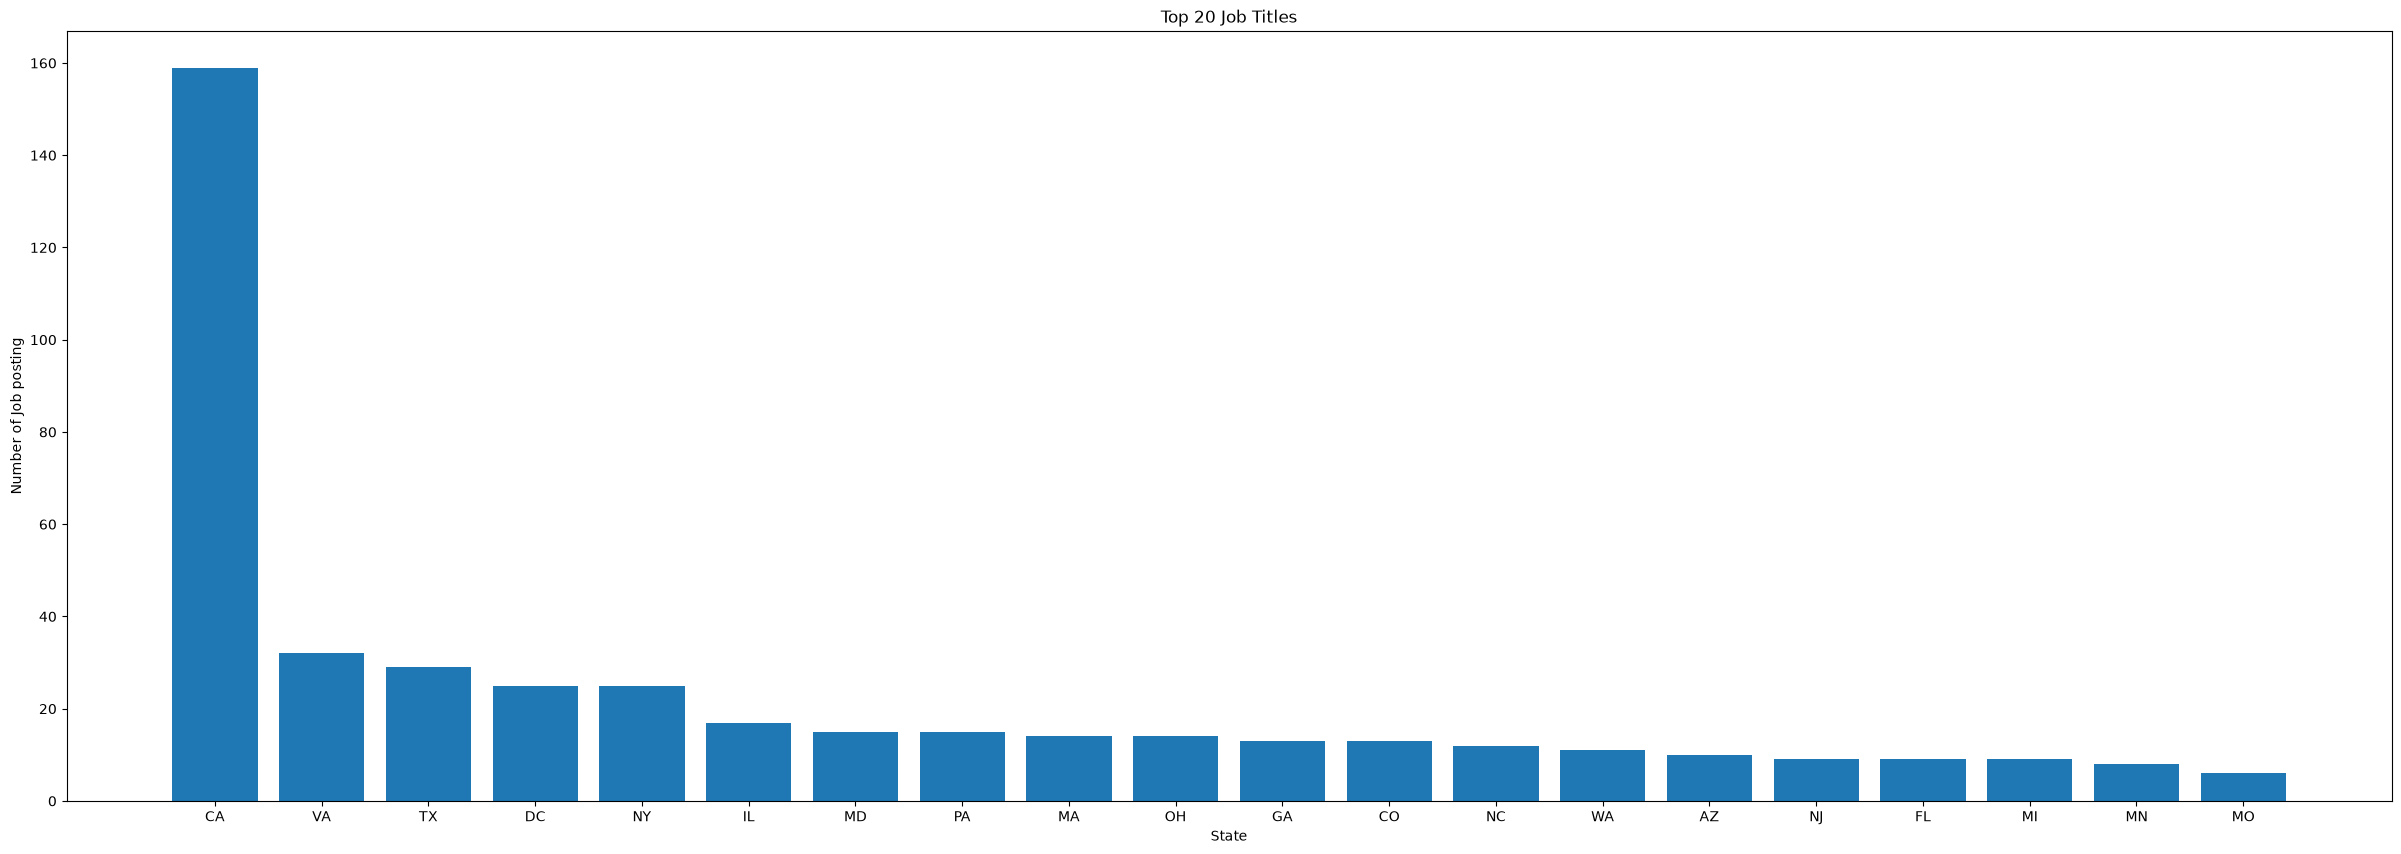

In [334]:
top_state = state_value.head(20)
plt.figure(figsize=(30,10))

plt.bar(top_state.index,
        top_state.values)

plt.xlabel("State")
plt.ylabel("Number of Job posting")
plt.title("Top 20 Job Titles")

plt.show()

In [335]:
jobs.head()

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.00,Master Data Management Tool Admin:--- Roles an...
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.2,246.0,97580.50,Software Engineer - Entry to Experienced Level...
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.3,200.0,24.18,Undergraduate Internship/Co-op Program - Data ...


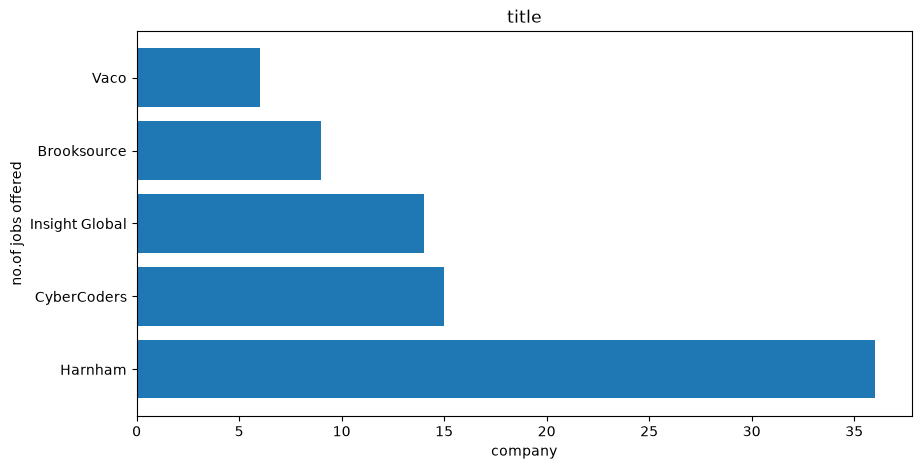

In [336]:
company_chart = jobs['company'].value_counts().head()
plt.figure(figsize=(10,5))

plt.barh(company_chart.index,
         company_chart.values)
plt.xlabel('company')
plt.ylabel('no.of jobs offered')
plt.title('title')

plt.show()

In [337]:
jobs['word_count'] = (jobs['description'].str.split().str.len())
jobs['word_count'].head()


2      476
10     173
11     264
13    1547
25     409
Name: word_count, dtype: int64

In [338]:
jobs['word_count'].describe()

count     496.000000
mean      415.423387
std       303.499385
min        37.000000
25%       223.750000
50%       341.500000
75%       492.250000
max      2221.000000
Name: word_count, dtype: float64

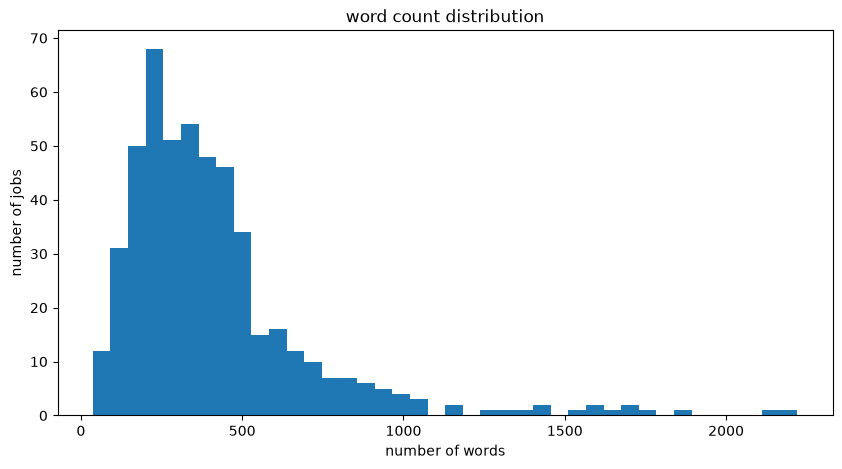

In [339]:
plt.figure(figsize=(10,5))

plt.hist(jobs['word_count'],
         bins=40)

plt.xlabel('number of words')
plt.ylabel('number of jobs')
plt.title('word count distribution')

plt.show()

In [340]:
from collections import Counter
import re

all_words = []

for text in jobs['description']:
    words = re.findall(
        r'\b[a-zA-Z]+\b',
        text.lower()
    )

    all_words.extend(words)

In [341]:
word_counts = Counter(all_words)

word_counts.most_common(30)

[('and', 10685),
 ('to', 6587),
 ('the', 5827),
 ('of', 4489),
 ('in', 3635),
 ('a', 3477),
 ('data', 3080),
 ('with', 2945),
 ('for', 2550),
 ('or', 2044),
 ('experience', 1899),
 ('is', 1611),
 ('you', 1499),
 ('be', 1373),
 ('will', 1288),
 ('work', 1274),
 ('as', 1250),
 ('on', 1248),
 ('s', 1100),
 ('are', 1069),
 ('our', 892),
 ('that', 870),
 ('we', 868),
 ('this', 864),
 ('years', 806),
 ('an', 806),
 ('required', 804),
 ('your', 803),
 ('business', 792),
 ('time', 749)]

In [342]:
from nltk.corpus import stopwords
import nltk

nltk.download('tokens')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Error loading tokens: Package 'tokens' not found in index
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhatt\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [343]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [344]:
filtered_words = []

for i in jobs['description']:
  words = re.findall(r'\b[a-zA-Z]+\b', i.lower())


  words = [word
           for word in words
           if word not in stop_words]

  filtered_words.extend(words)

In [345]:
word_counts = Counter(filtered_words)

word_counts.most_common(30)

[('data', 3080),
 ('experience', 1899),
 ('work', 1274),
 ('years', 806),
 ('required', 804),
 ('business', 792),
 ('time', 749),
 ('skills', 718),
 ('learning', 716),
 ('team', 662),
 ('job', 641),
 ('full', 578),
 ('position', 566),
 ('science', 519),
 ('development', 509),
 ('machine', 508),
 ('working', 502),
 ('information', 496),
 ('management', 470),
 ('analysis', 463),
 ('sql', 454),
 ('must', 453),
 ('computer', 449),
 ('requirements', 444),
 ('preferred', 440),
 ('ability', 436),
 ('company', 428),
 ('knowledge', 422),
 ('software', 415),
 ('systems', 401)]

In [346]:
jobs

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text,word_count
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.700000,272.000000,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...,476
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.800000,14581.000000,47500.00,Master Data Management Tool Admin:--- Roles an...,173
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.600000,9.000000,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...,264
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.200000,246.000000,97580.50,Software Engineer - Entry to Experienced Level...,1547
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.300000,200.000000,24.18,Undergraduate Internship/Co-op Program - Data ...,409
...,...,...,...,...,...,...,...,...,...,...,...,...
3174,Data Analyst,Summary:\nThe Marin City Health and Wellness C...,Marin City,CA,<NA>,65000 a year,Marin City Health and Wellness Center,3.940511,1406.087591,65000.00,Data Analyst:--- Summary:\nThe Marin City Heal...,643
3184,Junior Business Analyst,This is a long term temporary position with be...,New York,NY,<NA>,65000 - 75000 a year - Full-time Temporary,"Penda Aiken, Inc.",3.940511,1406.087591,67500.00,Junior Business Analyst:--- This is a long ter...,492
3185,SQL Data Analyst,Role: SQL Data Analyst with Healthcare Payer E...,Portland,OR,<NA>,55 - 60 an hour - Full-time Contract,Peopleforce INC,3.940511,1406.087591,67500.00,SQL Data Analyst:--- Role: SQL Data Analyst wi...,201
3186,Data Analyst -Entry Level Job ( Skill upgradat...,Roles & Responsibility of Data AnalystA data a...,Boston,MA,2199,50000 - 60000 a year - Full-time Part-time Te...,Jerneltechcorp,3.940511,1406.087591,67500.00,Data Analyst -Entry Level Job ( Skill upgradat...,207


In [347]:
skills = [
    "python",
    "sql",
    "r",
    "java",
    "c++",
    "javascript",
    "machine learning",
    "deep learning",
    "artificial intelligence",
    "tensorflow",
    "pytorch",
    "scikit-learn",
    "pandas",
    "numpy",
    "nlp",
    "natural language processing",
    "computer vision",
    "aws",
    "azure",
    "gcp",
    "google cloud",
    "docker",
    "kubernetes",
    "spark",
    "hadoop",
    "tableau",
    "power bi",
    "excel",
    "git",
    "github",
    "langchain",
    "langgraph",
    "rag",
    "faiss",
    "transformers",
    "hugging face",
    "fastapi",
    "flask",
    "django"
]

In [348]:
  text = text.lower()
  text


"data scientist\nif you are a data scientist with experience, please read on!\n\nbased in chicago, il, we are a first-class management consulting provider in financial planning; performance improvement; partnerships, mergers, and acquisitions; and treasury and capital markets.\n\ncurrently we are looking to bring on a data scientist to help us in efforts to transform data into insight to help our company advance a variety of our practices.\nwhat you will be doing\ndevelope creative and analytically driven solutions using operations research, advanced statistical and mathematical science techniques such as machine learning.\nutilize advanced mathematical and statistical methodologies to develop scenario modeling events.\ncreate complex models and algorithms drawing from large and complex data.\n\ntranslate nclient and consultant requirements and constraints into mathematical models.\nbuild analytical models to improve the financial and patient care metrics.\nparticipate in research to c

In [349]:
def extract_skill(text):

  text = text.lower()
  skills_list = []
  for skill in skills:
    if skill in text:
      skills_list.append(skill)
  return skills_list



In [350]:
jobs['skills'] = jobs['description'].apply(extract_skill)
jobs

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text,word_count,skills
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.700000,272.000000,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...,476,"[sql, r, java, javascript, tableau, excel, rag]"
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.800000,14581.000000,47500.00,Master Data Management Tool Admin:--- Roles an...,173,"[r, excel]"
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.600000,9.000000,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...,264,"[sql, r, tableau, git]"
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.200000,246.000000,97580.50,Software Engineer - Entry to Experienced Level...,1547,"[python, r, java, c++, machine learning, artif..."
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.300000,200.000000,24.18,Undergraduate Internship/Co-op Program - Data ...,409,"[r, git]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3174,Data Analyst,Summary:\nThe Marin City Health and Wellness C...,Marin City,CA,<NA>,65000 a year,Marin City Health and Wellness Center,3.940511,1406.087591,65000.00,Data Analyst:--- Summary:\nThe Marin City Heal...,643,"[sql, r, excel, rag]"
3184,Junior Business Analyst,This is a long term temporary position with be...,New York,NY,<NA>,65000 - 75000 a year - Full-time Temporary,"Penda Aiken, Inc.",3.940511,1406.087591,67500.00,Junior Business Analyst:--- This is a long ter...,492,"[r, excel]"
3185,SQL Data Analyst,Role: SQL Data Analyst with Healthcare Payer E...,Portland,OR,<NA>,55 - 60 an hour - Full-time Contract,Peopleforce INC,3.940511,1406.087591,67500.00,SQL Data Analyst:--- Role: SQL Data Analyst wi...,201,"[sql, r, excel, rag]"
3186,Data Analyst -Entry Level Job ( Skill upgradat...,Roles & Responsibility of Data AnalystA data a...,Boston,MA,2199,50000 - 60000 a year - Full-time Part-time Te...,Jerneltechcorp,3.940511,1406.087591,67500.00,Data Analyst -Entry Level Job ( Skill upgradat...,207,[r]


In [351]:
from collections import Counter

skill_counts = Counter()

for skill_list in jobs['skills']:
    skill_counts.update(skill_list)

In [352]:
skill_counts.most_common(20)

[('r', 496),
 ('sql', 220),
 ('excel', 208),
 ('machine learning', 189),
 ('python', 186),
 ('rag', 153),
 ('artificial intelligence', 103),
 ('java', 98),
 ('aws', 97),
 ('git', 72),
 ('deep learning', 62),
 ('tableau', 59),
 ('spark', 57),
 ('c++', 40),
 ('hadoop', 40),
 ('azure', 37),
 ('nlp', 37),
 ('javascript', 34),
 ('tensorflow', 34),
 ('computer vision', 34)]

In [353]:
jobs

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text,word_count,skills
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.700000,272.000000,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...,476,"[sql, r, java, javascript, tableau, excel, rag]"
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.800000,14581.000000,47500.00,Master Data Management Tool Admin:--- Roles an...,173,"[r, excel]"
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.600000,9.000000,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...,264,"[sql, r, tableau, git]"
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.200000,246.000000,97580.50,Software Engineer - Entry to Experienced Level...,1547,"[python, r, java, c++, machine learning, artif..."
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.300000,200.000000,24.18,Undergraduate Internship/Co-op Program - Data ...,409,"[r, git]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3174,Data Analyst,Summary:\nThe Marin City Health and Wellness C...,Marin City,CA,<NA>,65000 a year,Marin City Health and Wellness Center,3.940511,1406.087591,65000.00,Data Analyst:--- Summary:\nThe Marin City Heal...,643,"[sql, r, excel, rag]"
3184,Junior Business Analyst,This is a long term temporary position with be...,New York,NY,<NA>,65000 - 75000 a year - Full-time Temporary,"Penda Aiken, Inc.",3.940511,1406.087591,67500.00,Junior Business Analyst:--- This is a long ter...,492,"[r, excel]"
3185,SQL Data Analyst,Role: SQL Data Analyst with Healthcare Payer E...,Portland,OR,<NA>,55 - 60 an hour - Full-time Contract,Peopleforce INC,3.940511,1406.087591,67500.00,SQL Data Analyst:--- Role: SQL Data Analyst wi...,201,"[sql, r, excel, rag]"
3186,Data Analyst -Entry Level Job ( Skill upgradat...,Roles & Responsibility of Data AnalystA data a...,Boston,MA,2199,50000 - 60000 a year - Full-time Part-time Te...,Jerneltechcorp,3.940511,1406.087591,67500.00,Data Analyst -Entry Level Job ( Skill upgradat...,207,[r]


In [354]:
jobs

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text,word_count,skills
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.700000,272.000000,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...,476,"[sql, r, java, javascript, tableau, excel, rag]"
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.800000,14581.000000,47500.00,Master Data Management Tool Admin:--- Roles an...,173,"[r, excel]"
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.600000,9.000000,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...,264,"[sql, r, tableau, git]"
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.200000,246.000000,97580.50,Software Engineer - Entry to Experienced Level...,1547,"[python, r, java, c++, machine learning, artif..."
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.300000,200.000000,24.18,Undergraduate Internship/Co-op Program - Data ...,409,"[r, git]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3174,Data Analyst,Summary:\nThe Marin City Health and Wellness C...,Marin City,CA,<NA>,65000 a year,Marin City Health and Wellness Center,3.940511,1406.087591,65000.00,Data Analyst:--- Summary:\nThe Marin City Heal...,643,"[sql, r, excel, rag]"
3184,Junior Business Analyst,This is a long term temporary position with be...,New York,NY,<NA>,65000 - 75000 a year - Full-time Temporary,"Penda Aiken, Inc.",3.940511,1406.087591,67500.00,Junior Business Analyst:--- This is a long ter...,492,"[r, excel]"
3185,SQL Data Analyst,Role: SQL Data Analyst with Healthcare Payer E...,Portland,OR,<NA>,55 - 60 an hour - Full-time Contract,Peopleforce INC,3.940511,1406.087591,67500.00,SQL Data Analyst:--- Role: SQL Data Analyst wi...,201,"[sql, r, excel, rag]"
3186,Data Analyst -Entry Level Job ( Skill upgradat...,Roles & Responsibility of Data AnalystA data a...,Boston,MA,2199,50000 - 60000 a year - Full-time Part-time Te...,Jerneltechcorp,3.940511,1406.087591,67500.00,Data Analyst -Entry Level Job ( Skill upgradat...,207,[r]


In [355]:
skill_df = pd.DataFrame(
    skill_counts.most_common(20),
    columns=['Skill', 'Job_Count']
)

display(skill_df)

,Skill,Job_Count
0,r,496
1,sql,220
2,excel,208
3,machine learning,189
4,python,186
5,rag,153
6,artificial intelligence,103
7,java,98
8,aws,97
9,git,72


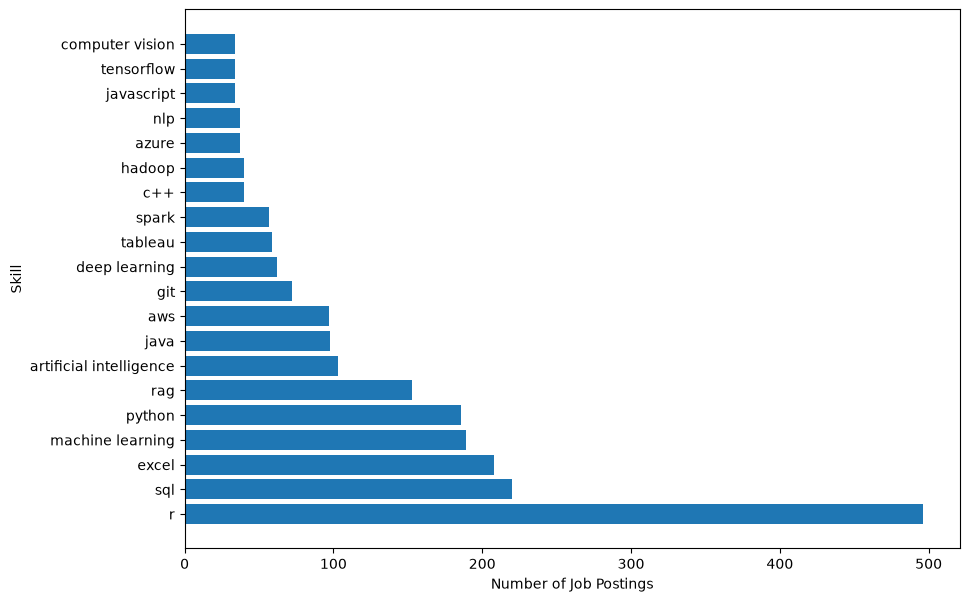

In [356]:
plt.figure(figsize=(10,7))
plt.barh(skill_df['Skill'],
         skill_df['Job_Count'])
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.show()


In [357]:
jobs.head()

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text,word_count,skills
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...,476,"[sql, r, java, javascript, tableau, excel, rag]"
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.00,Master Data Management Tool Admin:--- Roles an...,173,"[r, excel]"
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...,264,"[sql, r, tableau, git]"
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.2,246.0,97580.50,Software Engineer - Entry to Experienced Level...,1547,"[python, r, java, c++, machine learning, artif..."
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.3,200.0,24.18,Undergraduate Internship/Co-op Program - Data ...,409,"[r, git]"


In [358]:
jobs['skill_count'] = jobs['skills'].apply(len)
jobs

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text,word_count,skills,skill_count
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.700000,272.000000,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...,476,"[sql, r, java, javascript, tableau, excel, rag]",7
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.800000,14581.000000,47500.00,Master Data Management Tool Admin:--- Roles an...,173,"[r, excel]",2
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.600000,9.000000,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...,264,"[sql, r, tableau, git]",4
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.200000,246.000000,97580.50,Software Engineer - Entry to Experienced Level...,1547,"[python, r, java, c++, machine learning, artif...",9
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.300000,200.000000,24.18,Undergraduate Internship/Co-op Program - Data ...,409,"[r, git]",2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3174,Data Analyst,Summary:\nThe Marin City Health and Wellness C...,Marin City,CA,<NA>,65000 a year,Marin City Health and Wellness Center,3.940511,1406.087591,65000.00,Data Analyst:--- Summary:\nThe Marin City Heal...,643,"[sql, r, excel, rag]",4
3184,Junior Business Analyst,This is a long term temporary position with be...,New York,NY,<NA>,65000 - 75000 a year - Full-time Temporary,"Penda Aiken, Inc.",3.940511,1406.087591,67500.00,Junior Business Analyst:--- This is a long ter...,492,"[r, excel]",2
3185,SQL Data Analyst,Role: SQL Data Analyst with Healthcare Payer E...,Portland,OR,<NA>,55 - 60 an hour - Full-time Contract,Peopleforce INC,3.940511,1406.087591,67500.00,SQL Data Analyst:--- Role: SQL Data Analyst wi...,201,"[sql, r, excel, rag]",4
3186,Data Analyst -Entry Level Job ( Skill upgradat...,Roles & Responsibility of Data AnalystA data a...,Boston,MA,2199,50000 - 60000 a year - Full-time Part-time Te...,Jerneltechcorp,3.940511,1406.087591,67500.00,Data Analyst -Entry Level Job ( Skill upgradat...,207,[r],1


**Phase 2--Feature Engineering**

In [359]:
jobs['title'].value_counts().head(10)

title
Data Scientist                  35
Data Analyst                    19
Senior Data Scientist            8
Data Engineer                    7
Business Analyst                 7
Entry Level Business Analyst     5
Machine Learning Engineer        5
Sr. Data Analyst                 3
Senior Data Analyst              3
Data Manager                     3
Name: count, dtype: int64

In [360]:
import yaml

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)


In [361]:
config[
    "job_categories"
]

[{'category': 'Machine Learning Engineer',
  'keywords': ['machine learning engineer',
   'ml engineer',
   'machine learning developer',
   'ml developer']},
 {'category': 'Data Scientist',
  'keywords': ['data scientist',
   'data science',
   'applied scientist',
   'research scientist']},
 {'category': 'Data Analyst',
  'keywords': ['data analyst', 'data analytics', 'analytics analyst']},
 {'category': 'Data Engineer',
  'keywords': ['data engineer',
   'data engineering',
   'etl developer',
   'big data developer',
   'big data/hadoop developer',
   'hadoop developer',
   'data warehouse developer',
   'data integration engineer',
   'data integration specialist',
   'data integration officer',
   'data migration engineer',
   'data migration and conversion specialist',
   'data migration',
   'informatica idq developer',
   'data warehouse consultant',
   'data modeler']},
 {'category': 'Software Engineer',
  'keywords': ['software engineer',
   'software developer',
   'softwar

In [362]:
jobs.head(5)

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text,word_count,skills,skill_count
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...,476,"[sql, r, java, javascript, tableau, excel, rag]",7
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.00,Master Data Management Tool Admin:--- Roles an...,173,"[r, excel]",2
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...,264,"[sql, r, tableau, git]",4
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.2,246.0,97580.50,Software Engineer - Entry to Experienced Level...,1547,"[python, r, java, c++, machine learning, artif...",9
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.3,200.0,24.18,Undergraduate Internship/Co-op Program - Data ...,409,"[r, git]",2


In [363]:
def categorize(title):
  title = title.lower()   

  for item in config["job_categories"]:
    category = item['category']
    keywords = item['keywords']

    for keyword in keywords:
      if keyword in title:
        return category 

  return 'Others'  
        

In [364]:
jobs['category'] = jobs['title'].apply(categorize)
jobs.head(5)

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text,word_count,skills,skill_count,category
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.00,BI Developer (Tableau):--- **U.S. Citizens and...,476,"[sql, r, java, javascript, tableau, excel, rag]",7,Business Intelligence
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.00,Master Data Management Tool Admin:--- Roles an...,173,"[r, excel]",2,Others
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.00,Senior Web Data Analyst - SQL:--- Senior Web D...,264,"[sql, r, tableau, git]",4,Data Analyst
13,Software Engineer - Entry to Experienced Level...,Job Summary\nNSA is in search of Computer Scie...,Fort Gordon,GA,<NA>,83692 - 111469 a year,National Security Agency,4.2,246.0,97580.50,Software Engineer - Entry to Experienced Level...,1547,"[python, r, java, c++, machine learning, artif...",9,Software Engineer
25,Undergraduate Internship/Co-op Program - Data ...,As a Data Scientist Undergraduate Intern for t...,Washington,DC,<NA>,21.93 - 26.43 an hour,Central Intelligence Agency,4.3,200.0,24.18,Undergraduate Internship/Co-op Program - Data ...,409,"[r, git]",2,Data Scientist


In [365]:
jobs[jobs['category'] == 'Others']['title'].value_counts()

title
Database Architect                                        2
Variable Data Programmer                                  2
Oracle Developer                                          2
Account Executive                                         2
Master Data Management Tool Admin                         1
                                                         ..
Client Concierge Manager                                  1
Machine Learning/Natural Language Generation Scientist    1
Senior Guidewire Developer                                1
Quality Engineer, Senior                                  1
Dance4Healing looking for Computer Science students       1
Name: count, Length: 116, dtype: int64

In [366]:
category_count = jobs['category'].value_counts()

In [367]:
jobs['category'].unique()

<StringArray>
[          'Business Intelligence',                          'Others',
                    'Data Analyst',               'Software Engineer',
                  'Data Scientist',                        'Database',
    'Product & Project Management', 'AI/ML Research & Specialized AI',
                   'Data Engineer',       'Machine Learning Engineer',
       'Data Quality & Operations',                  'Cloud Engineer',
                'Business Analyst',  'Data Architecture & Management',
                     'AI Engineer',              'Research & Science']
Length: 16, dtype: str

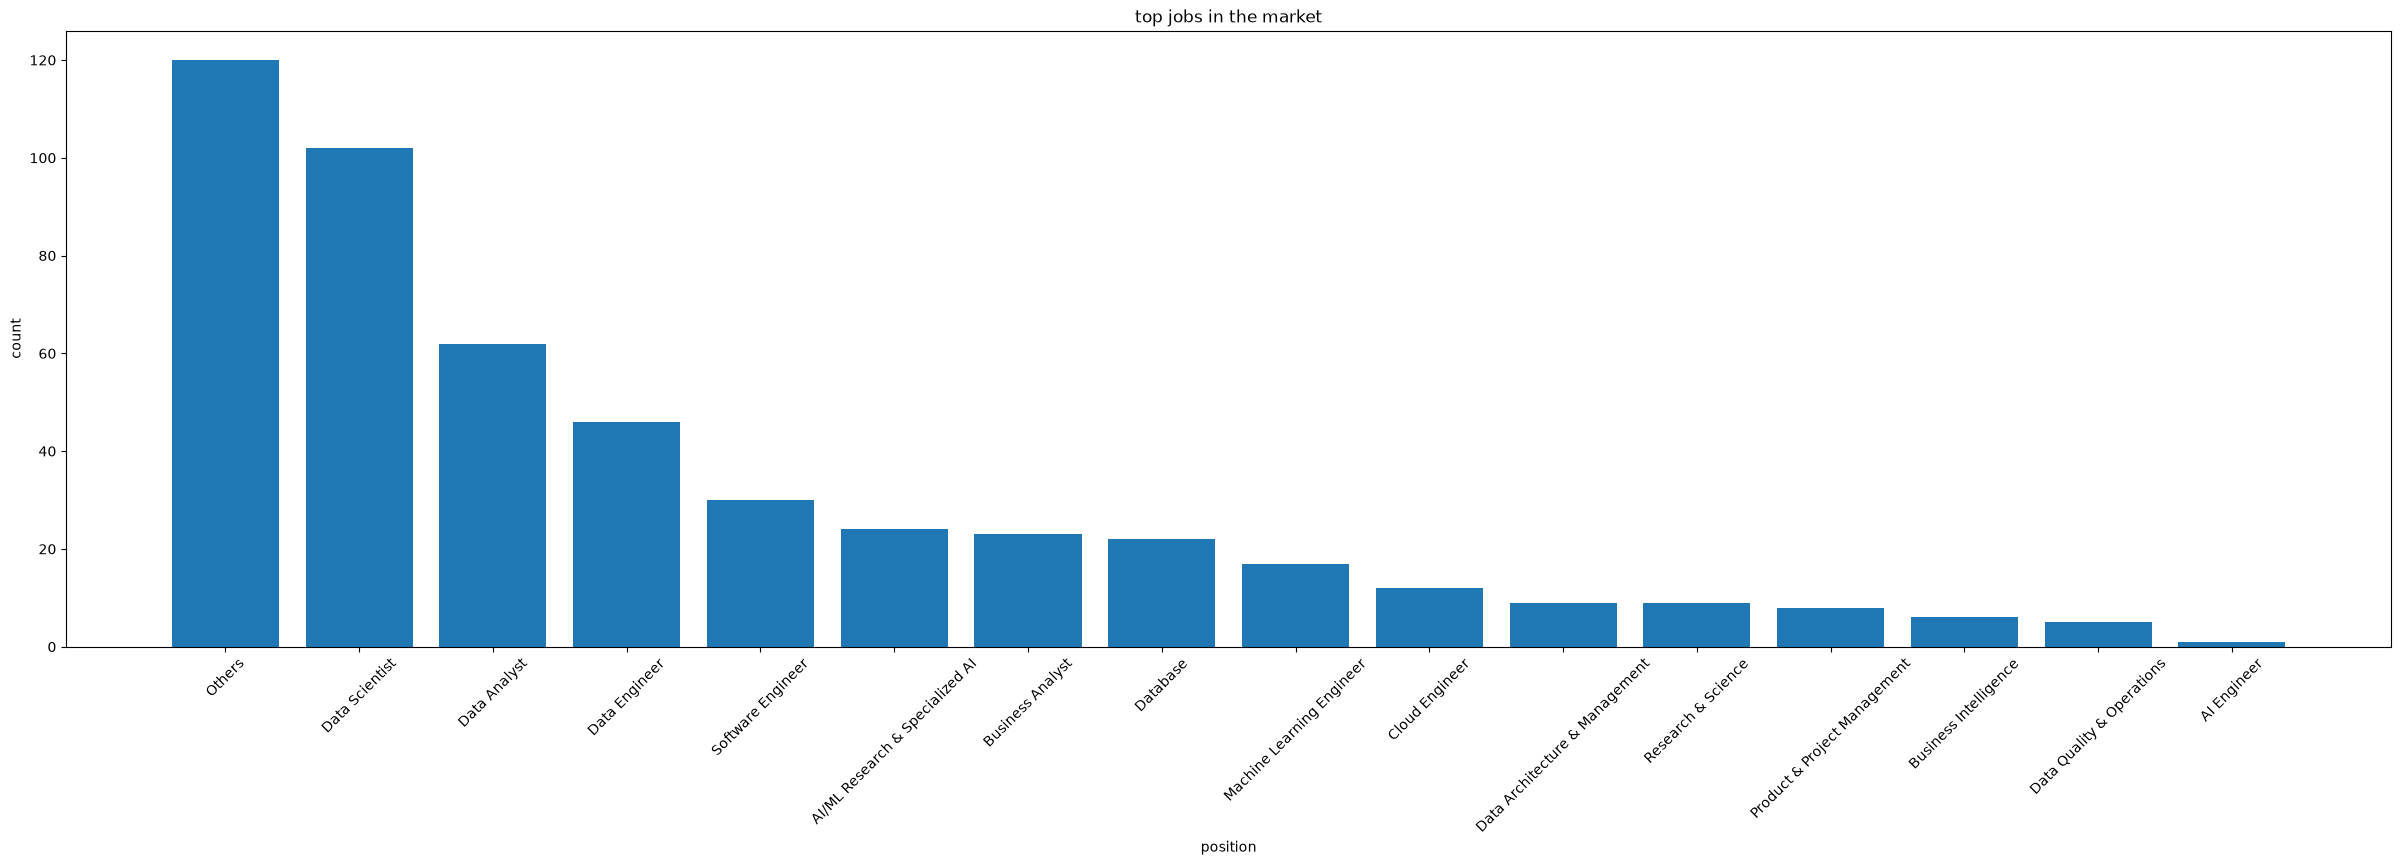

In [368]:
plt.figure(figsize=(30,8))
plt.bar(category_count.index,
        category_count.values)

plt.xlabel('position')
plt.ylabel('count')
plt.title("top jobs in the market")

plt.xticks(rotation=45)
plt.show()

In [369]:
jobs.head(3)

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text,word_count,skills,skill_count,category
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.0,BI Developer (Tableau):--- **U.S. Citizens and...,476,"[sql, r, java, javascript, tableau, excel, rag]",7,Business Intelligence
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.0,Master Data Management Tool Admin:--- Roles an...,173,"[r, excel]",2,Others
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.0,Senior Web Data Analyst - SQL:--- Senior Web D...,264,"[sql, r, tableau, git]",4,Data Analyst


In [370]:
jobs['category'].value_counts(normalize=True)*100

category
Others                             24.193548
Data Scientist                     20.564516
Data Analyst                       12.500000
Data Engineer                       9.274194
Software Engineer                   6.048387
AI/ML Research & Specialized AI     4.838710
Business Analyst                    4.637097
Database                            4.435484
Machine Learning Engineer           3.427419
Cloud Engineer                      2.419355
Data Architecture & Management      1.814516
Research & Science                  1.814516
Product & Project Management        1.612903
Business Intelligence               1.209677
Data Quality & Operations           1.008065
AI Engineer                         0.201613
Name: proportion, dtype: float64

In [371]:
jobs.head(3)

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,job_text,word_count,skills,skill_count,category
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.0,BI Developer (Tableau):--- **U.S. Citizens and...,476,"[sql, r, java, javascript, tableau, excel, rag]",7,Business Intelligence
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.0,Master Data Management Tool Admin:--- Roles an...,173,"[r, excel]",2,Others
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.0,Senior Web Data Analyst - SQL:--- Senior Web D...,264,"[sql, r, tableau, git]",4,Data Analyst


In [372]:
for skill in skills:
 jobs[skill] = jobs['skills'].apply(lambda x: int(skill in x))

In [373]:
jobs.head(3)

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,...,github,langchain,langgraph,rag,faiss,transformers,hugging face,fastapi,flask,django
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.0,...,0,0,0,1,0,0,0,0,0,0
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.0,...,0,0,0,0,0,0,0,0,0,0
11,Senior Web Data Analyst - SQL,"Senior Web Data Analyst - SQL\nLos Angeles, CA...",Los Angeles,CA,<NA>,120000 a year,Harnham,4.6,9.0,120000.0,...,0,0,0,0,0,0,0,0,0,0


In [374]:
jobs.head(2)

,title,description,city,state,zipcode,salary,company,rating,reviews,clean_salary,...,github,langchain,langgraph,rag,faiss,transformers,hugging face,fastapi,flask,django
2,BI Developer (Tableau),**U.S. Citizens and those authorized to work i...,Charlotte,NC,28202,97000 a year,Vaco,3.7,272.0,97000.0,...,0,0,0,1,0,0,0,0,0,0
10,Master Data Management Tool Admin,Roles and Responsibilities: Manage Product mas...,Houston,TX,<NA>,45000 - 50000 a year,Wipro,3.8,14581.0,47500.0,...,0,0,0,0,0,0,0,0,0,0


In [375]:
skills_by_category = jobs.groupby('category')[skills].mean()
skills_by_category

,python,sql,r,java,c++,javascript,machine learning,deep learning,artificial intelligence,tensorflow,...,github,langchain,langgraph,rag,faiss,transformers,hugging face,fastapi,flask,django
category,,,,,,,,,,,,,,,,,,,,,
AI Engineer,0.000000,0.000000,1.0,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000
AI/ML Research & Specialized AI,0.666667,0.083333,1.0,0.208333,0.375000,0.083333,0.833333,0.583333,0.333333,0.416667,...,0.041667,0.0,0.0,0.166667,0.000000,0.0,0.0,0.0,0.041667,0.000000
Business Analyst,0.086957,0.347826,1.0,0.000000,0.000000,0.000000,0.043478,0.000000,0.043478,0.000000,...,0.000000,0.0,0.0,0.173913,0.000000,0.0,0.0,0.0,0.000000,0.000000
Business Intelligence,0.000000,0.833333,1.0,0.166667,0.000000,0.166667,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.333333,0.000000,0.0,0.0,0.0,0.000000,0.000000
Cloud Engineer,0.500000,0.500000,1.0,0.250000,0.083333,0.000000,0.250000,0.000000,0.583333,0.000000,...,0.000000,0.0,0.0,0.250000,0.000000,0.0,0.0,0.0,0.000000,0.000000
Data Analyst,0.177419,0.580645,1.0,0.064516,0.016129,0.016129,0.064516,0.032258,0.000000,0.016129,...,0.000000,0.0,0.0,0.177419,0.000000,0.0,0.0,0.0,0.000000,0.000000
Data Architecture & Management,0.222222,0.333333,1.0,0.333333,0.000000,0.111111,0.222222,0.000000,0.000000,0.000000,...,0.111111,0.0,0.0,0.666667,0.000000,0.0,0.0,0.0,0.000000,0.000000
Data Engineer,0.434783,0.695652,1.0,0.217391,0.000000,0.043478,0.108696,0.021739,0.021739,0.000000,...,0.000000,0.0,0.0,0.282609,0.000000,0.0,0.0,0.0,0.000000,0.000000
Data Quality & Operations,0.000000,0.200000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,...,0.000000,0.0,0.0,0.400000,0.000000,0.0,0.0,0.0,0.000000,0.000000


Text(50.38563368055553, 0.5, 'Category')

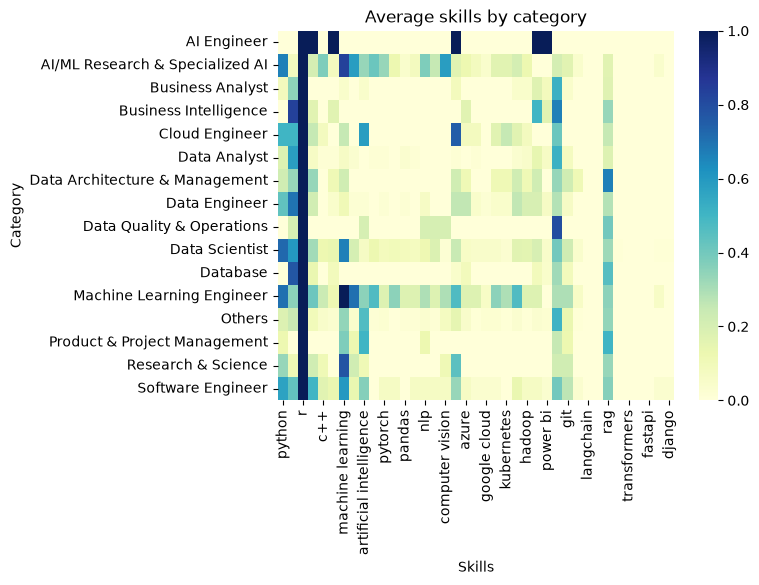

In [376]:
import seaborn as sn
plt.Figure(figsize=(10,6))

sn.heatmap(skills_by_category, cmap='YlGnBu')

plt.title("Average skills by category")
plt.xlabel('Skills')
plt.ylabel('Category')


#Phase 3 Machine Learning

In [377]:
jobs.isna().sum()

title                            0
description                      0
city                             0
state                            0
zipcode                        252
salary                           0
company                          0
rating                           0
reviews                          0
clean_salary                     0
job_text                         0
word_count                       0
skills                           0
skill_count                      0
category                         0
python                           0
sql                              0
r                                0
java                             0
c++                              0
javascript                       0
machine learning                 0
deep learning                    0
artificial intelligence          0
tensorflow                       0
pytorch                          0
scikit-learn                     0
pandas                           0
numpy               

In [378]:
jobs['clean_salary'].isna().any()

np.False_

In [379]:
jobs.isna().sum()

title                            0
description                      0
city                             0
state                            0
zipcode                        252
salary                           0
company                          0
rating                           0
reviews                          0
clean_salary                     0
job_text                         0
word_count                       0
skills                           0
skill_count                      0
category                         0
python                           0
sql                              0
r                                0
java                             0
c++                              0
javascript                       0
machine learning                 0
deep learning                    0
artificial intelligence          0
tensorflow                       0
pytorch                          0
scikit-learn                     0
pandas                           0
numpy               

In [380]:
counts = jobs['category'].value_counts()

In [381]:
valid_classes = counts[counts >= 2].index
jobs_clean = jobs[jobs['category'].isin(valid_classes)]

In [382]:
others = jobs[jobs['category'] == 'Others']

print(
    others['title']
    .value_counts()
    .head(50)
)

title
Database Architect                                                                                   2
Variable Data Programmer                                                                             2
Oracle Developer                                                                                     2
Account Executive                                                                                    2
Master Data Management Tool Admin                                                                    1
Oracle DBA                                                                                           1
Donor Database Coordinator                                                                           1
Chief Marketing Officer (CMO)                                                                        1
2020034 Data Scientest $170,000.00                                                                   1
Senior Accountant                                                  

# Phase 3 Building Model

In [406]:
feature_columns = [
    'clean_salary',
    'rating',
    'reviews',
    'word_count',
    'skill_count'
]

feature_columns += skills


In [407]:
X = jobs_clean[['title'] + feature_columns]

In [408]:
Y = jobs_clean['category']
Y

2       Business Intelligence
10                     Others
11               Data Analyst
13          Software Engineer
25             Data Scientist
                ...          
3174             Data Analyst
3184         Business Analyst
3185             Data Analyst
3186             Data Analyst
3189           Data Scientist
Name: category, Length: 495, dtype: str

In [409]:
print(X.shape)
print(Y.shape)

(495, 45)
(495,)


In [410]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [411]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        
        # Convert title text → numerical TF-IDF features
        (
            'title_tfidf',
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2
            ),
            'title'
        ),
        
        # Scale numerical + skill features
        (
            'numeric',
            StandardScaler(),
            feature_columns
        )
    ]
)

In [412]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    
    ('classifier', LogisticRegression(
        max_iter=2000
    ))
])

In [413]:
model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](15,)","['AI/ML Research & Specialized AI','Business Analyst', 'Business Intelligence',...,'Product & Project Management', 'Research & Science','Software Engineer']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](45,)","['title','clean_salary','rating',...,'fastapi','flask','django']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,45
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('title_tfidf', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transfo

In [414]:
model.score(x_test, y_test)

0.696969696969697

-----------debug start----------------------------

In [392]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2
    )),
    ('classifier', LogisticRegression(
        max_iter=2000
    ))
])

In [393]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    jobs_clean['title'].fillna(''),
    jobs_clean['category'],
    test_size=0.2,
    random_state=42,
    stratify=jobs_clean['category']
)

In [396]:
x_test

170                                   Senior Data Analyst
594                        Sr. SQL Database Administrator
497                              Variable Data Programmer
1998                                         Data Manager
1980                                   Research Associate
                              ...                        
40                                     Database Developer
3088                           Documentation/Data Analyst
3123                                         Data Manager
2701                    SENIOR MACHINE LEARNING SCIENTIST
1743    Angular/Javascript/SQL Dev - Temporary - 6-mon...
Name: title, Length: 99, dtype: str

In [394]:
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [395]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8383838383838383
                                 precision    recall  f1-score   support

AI/ML Research & Specialized AI       1.00      0.60      0.75         5
               Business Analyst       1.00      1.00      1.00         5
          Business Intelligence       0.00      0.00      0.00         1
                 Cloud Engineer       0.00      0.00      0.00         2
                   Data Analyst       0.92      1.00      0.96        12
 Data Architecture & Management       0.00      0.00      0.00         2
                  Data Engineer       1.00      0.78      0.88         9
      Data Quality & Operations       0.00      0.00      0.00         1
                 Data Scientist       1.00      0.95      0.98        21
                       Database       1.00      1.00      1.00         4
      Machine Learning Engineer       1.00      1.00      1.00         3
                         Others       0.61      0.96      0.74        24
   Product & Project 

c:\Users\bhatt\OneDrive\Desktop\LUCIDEX\Job Parser\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bhatt\OneDrive\Desktop\LUCIDEX\Job Parser\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bhatt\OneDrive\Desktop\LUCIDEX\Job Parser\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

--------------debug end-----------

In [387]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

In [388]:
print(Y.value_counts())

category
Others                             120
Data Scientist                     102
Data Analyst                        62
Data Engineer                       46
Software Engineer                   30
AI/ML Research & Specialized AI     24
Business Analyst                    23
Database                            22
Machine Learning Engineer           17
Cloud Engineer                      12
Data Architecture & Management       9
Research & Science                   9
Product & Project Management         8
Business Intelligence                6
Data Quality & Operations            5
Name: count, dtype: int64


In [390]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2
    )),
    ('classifier', LogisticRegression(
        max_iter=2000
    ))
])

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.21212121212121213

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                                 precision    recall  f1-score   support

AI/ML Research & Specialized AI       0.00      0.00      0.00         5
               Business Analyst       0.00      0.00      0.00         5
          Business Intelligence       0.00      0.00      0.00         1
                 Cloud Engineer       0.00      0.00      0.00         2
                   Data Analyst       0.00      0.00      0.00        12
 Data Architecture & Management       0.00      0.00      0.00         2
                  Data Engineer       0.00      0.00      0.00         9
      Data Quality & Operations       0.00      0.00      0.00         1
                 Data Scientist       0.21      0.62      0.31        21
                       Database       0.00      0.00      0.00         4
      Machine Learning Engineer       0.00      0.00      0.00         3
                         Others       0.22      0.33      0.26        24
   Product & Project Management       0.00      0.

c:\Users\bhatt\OneDrive\Desktop\LUCIDEX\Job Parser\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bhatt\OneDrive\Desktop\LUCIDEX\Job Parser\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bhatt\OneDrive\Desktop\LUCIDEX\Job Parser\.venv-1\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
y_pred_rf = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred_rf)
accuracy

0.21212121212121213

In [ ]:
from sklearn import svm

clf = svm.SVC()
clf.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [ ]:
y_pred_svm = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred_svm)
accuracy

0.21212121212121213

In [ ]:
Y.value_counts(normalize=True).mul(100).round(2)

category
Others                             24.24
Data Scientist                     20.61
Data Analyst                       12.53
Data Engineer                       9.29
Software Engineer                   6.06
AI/ML Research & Specialized AI     4.85
Business Analyst                    4.65
Database                            4.44
Machine Learning Engineer           3.43
Cloud Engineer                      2.42
Data Architecture & Management      1.82
Research & Science                  1.82
Product & Project Management        1.62
Business Intelligence               1.21
Data Quality & Operations           1.01
Name: proportion, dtype: float64